Импорт библиотек

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

Берем данные (как я делал в кагле)

In [2]:
DATA_PATH = "/kaggle/input/datasets/erritter/data-one"

def load_and_clean_data(DATA_PATH):
    customers = pd.read_csv(f"{DATA_PATH}/olist_customers_dataset.csv")
    order_items = pd.read_csv(f"{DATA_PATH}/olist_order_items_dataset.csv")
    order_payments = pd.read_csv(f"{DATA_PATH}/olist_order_payments_dataset.csv")
    orders = pd.read_csv(f"{DATA_PATH}/olist_orders_dataset.csv")
    products = pd.read_csv(f"{DATA_PATH}/olist_products_dataset.csv")
    sellers = pd.read_csv(f"{DATA_PATH}/olist_sellers_dataset.csv")
    category_name_t = pd.read_csv(f"{DATA_PATH}/product_category_name_translation.csv")
    geolocation = pd.read_csv(f"{DATA_PATH}/olist_geolocation_dataset.csv")
    review = pd.read_csv(f"{DATA_PATH}/olist_order_reviews_dataset.csv")

    # фичи из orders
    orders["is_delivered"] = orders["order_delivered_customer_date"].notna().astype('int32')
    orders["is_approved"] = orders["order_approved_at"].notna().astype('int32')

    orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
    orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

    orders["delivery_days"] = (
        orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
    ).dt.days

    orders["delivery_days"] = orders["delivery_days"].fillna(-1)

    orders["is_delayed"] = (
        (orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]) &
        (orders["is_delivered"] == 1)
    ).astype('int32')

    # чистим products
    products["product_category_name"] = products["product_category_name"].fillna("unknown")

    for col in ["product_name_lenght", "product_description_lenght", "product_photos_qty"]:
        products[col] = products[col].fillna(0)

    for col in ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]:
        products[col] = products[col].fillna(products[col].median())

    return {
        "customers": customers,
        "geolocation": geolocation,
        "order_items": order_items,
        "order_payments": order_payments,
        "orders": orders,
        "products": products,
        "sellers": sellers,
        "category_name_t": category_name_t,
        "review": review
    }

Мержим

In [3]:
def merge_data(data):
    # Агрегируем платежи до уровня заказа
    # Складываем суммы платежей и берем макс. кол-во рассрочек
    payments_agg = data["order_payments"].groupby("order_id").agg({
        "payment_value": "sum",
        "payment_installments": "max"
    }).reset_index()

    # Мержим агрегированные платежи
    df = data["orders"] \
        .merge(data["order_items"], on="order_id", how="left") \
        .merge(data["products"], on="product_id", how="left") \
        .merge(data["customers"], on="customer_id", how="left") \
        .merge(data["sellers"], on="seller_id", how="left") \
        .merge(payments_agg, on="order_id", how="left") # Используем agg

    return df

In [4]:
# Фич инженеринг
def create_features(df):
    """
    Дополнительные признаки
    """

    # объем
    df["product_volume"] = (
        df["product_length_cm"] *
        df["product_height_cm"] *
        df["product_width_cm"]
    )

    # время
    df["order_month"] = df["order_purchase_timestamp"].dt.month
    df["order_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek

    return df

In [5]:
def create_target(df):
    """
    Создаем таргет
    """
    COST_PER_GRAM = 0.02

    df["estimated_cost"] = df["product_weight_g"] * COST_PER_GRAM
    df["total_cost"] = df["estimated_cost"] + df["freight_value"]

    df["profit"] = df["price"] - df["total_cost"]

    df["profit_margin"] = df["profit"] / (df["total_cost"] + 1e-6)

    df["target"] = (df["profit_margin"] >= 0.2).astype('int32')

    return df

In [6]:
def encode_categories(df):
    """
    Простое кодирование категорий
    """

    cat_cols = [
        "customer_state",
        "seller_state",
        "product_category_name"
    ]

    for col in cat_cols:
        df[col] = df[col].astype("category").cat.codes

    return df

def final_clean(df):
    """
    Финальная зачистка после merge
    """

    # удаляем строки без ключевых числовых признаков
    df = df.dropna(subset=[
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
        "product_photos_qty"
    ]).copy()
    
    # категории
    df["customer_state"] = df["customer_state"].fillna("unknown")
    df["seller_state"] = df["seller_state"].fillna("unknown")

    return df

In [7]:
def build_dataset(data_path=DATA_PATH):
    """
    Полный pipeline подготовки данных
    """

    data = load_and_clean_data(data_path)
    df = merge_data(data)
    df = final_clean(df)
    df = create_features(df)
    df = create_target(df)
    df = encode_categories(df)
    
    return df

In [8]:
# Собираем датасет
df = build_dataset()

print(df.columns.tolist())
print(df.shape)
df.head()


# Наши фичи
features = [
    'delivery_days',
    'is_delayed',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_photos_qty',
    'customer_state',
    'seller_state',
    'product_category_name',
    'product_volume',
    'order_month',       
    'order_dayofweek'
]

df = df.sample(30000, random_state=2804)

# Сортируем по дате 
df_sorted = df.sort_values("order_purchase_timestamp")

# Разделяем признаки и таргет
X_all = df_sorted[features]
y_all = df_sorted["target"]

# 80% данных (прошлое) - на обучение, 20% (будущее) - на тест
split_index = int(len(X_all) * 0.8)

X_train = X_all.iloc[:split_index]
y_train = y_all.iloc[:split_index]

X_test = X_all.iloc[split_index:]
y_test = y_all.iloc[split_index:]

print(f"Train period: {df_sorted['order_purchase_timestamp'].iloc[0].date()} — {df_sorted['order_purchase_timestamp'].iloc[split_index-1].date()}")
print(f"Test period: {df_sorted['order_purchase_timestamp'].iloc[split_index].date()} — {df_sorted['order_purchase_timestamp'].iloc[-1].date()}")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Features:", X_train.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_delivered', 'is_approved', 'delivery_days', 'is_delayed', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_value', 'payment_installments', 'product_volume', 'order_month', 'order_dayofweek', 'estimated_cost', 'total_cost', 'profit', 'profit_margin', 'target']
(112650, 43)
Train period: 2016-09-15 — 2018-05-21
Test period: 2018-05-21 — 2018-08-29
Train shape: (24000, 12)
Test shape: (6000, 12)
Features: ['delivery_days', 'is_

In [9]:
# Масштабируем признаки (но только те, что чувствительны к масштабу)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    
# Задаем параметры моделей
models = {
    "logreg": LogisticRegression(max_iter=2000, random_state = 2804),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "svm": SVC(kernel="linear", probability=True),
    "random_forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state = 2804),
    "gradient_boosting": GradientBoostingClassifier(random_state = 2804)
}

Обучаем модели

In [10]:
results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(X_test_scaled)[:, 1]
    score = roc_auc_score(y_test, probs)

    results.append({
        "Model": name,
        "ROC-AUC": score
    })

    print(f"{name}: {score:.4f}")

Training logreg...
logreg: 0.6688
Training knn...
knn: 0.6685
Training svm...
svm: 0.6585
Training random_forest...
random_forest: 0.8044
Training gradient_boosting...
gradient_boosting: 0.7477


Смотрим результаты

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,ROC-AUC
3,random_forest,0.804449
4,gradient_boosting,0.747672
0,logreg,0.668817
1,knn,0.668459
2,svm,0.658541


Самым точным оказался RF, на втором месте GB, а в самом конце только SVM. Предположения почему так получилось приведу в reportе

ЧАСТЬ 2: Подбор гиперпараметров

2.1 Подбираем для нашего лидера RF

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15, 20]
}

rf = RandomForestClassifier(n_jobs=-1)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'max_depth': 20, 'n_estimators': 300}
Best score: 0.8463030456810551


Копать дальше смылса не вижу, потому что 0.04 оч хороший прирост, а дальнейшее обучение может привести  к незначительным (а местами рандомным) приростам на 0.001-0.002. Поэтому топаем дальше

2.2 Подбор для GB

In [13]:
param_grid_gb = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7, 9]
}

gb = GradientBoostingClassifier()

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best params GB:", grid_gb.best_params_)
print("Best score GB:", grid_gb.best_score_)

Best params GB: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 400}
Best score GB: 0.8365471529485271


Получили очень приятный прирост практически на 0.1, можем постараться выбить еще побольше

In [14]:
param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7, 9, 10, 11]
}

gb = GradientBoostingClassifier()

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best params GB:", grid_gb.best_params_)
print("Best score GB:", grid_gb.best_score_)

Best params GB: {'learning_rate': 0.05, 'max_depth': 11, 'n_estimators': 200}
Best score GB: 0.8374748528258952


Вот тут пожалуй остановимся, относительно прошлого выросло всего на 0.001, а значит копать дальше смысла нет. Топаем дальше

2.3 Подбираем для KNN (ради интереса)

In [15]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=3,
    scoring="roc_auc"
)

grid_knn.fit(X_train, y_train)

print("Best params KNN:", grid_knn.best_params_)
print("Best score KNN:", grid_knn.best_score_)

Best params KNN: {'n_neighbors': 7}
Best score KNN: 0.7700389178622108


Неплохо вырос, аж на 0.11, больше чем первая версия бустинга

Когда делал GS для LogReg, понял, что не то подал для KNN (без масштабирования). Изменил ниже

In [21]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=3,
    scoring="roc_auc"
)

grid_knn.fit(X_train_scaled, y_train)

print("Best params KNN:", grid_knn.best_params_)
print("Best score KNN:", grid_knn.best_score_)

Best params KNN: {'n_neighbors': 11}
Best score KNN: 0.7075200336764103


Результат убил, на 0.07 меньше. Видимо модели было проще не с масштабируемыми данными. 

2.4 Попробуем подобрать для LogReg

In [23]:
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['liblinear', 'saga', 'lbfgs'],
    'penalty': ['l2'], 
    'max_iter': [1000, 2000, 3000]
}

logreg = LogisticRegression(random_state=2804)

grid_logreg = GridSearchCV(
    logreg,
    param_grid_logreg,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(X_train_scaled, y_train)

print("Best params:", grid_logreg.best_params_)
print("Best LR score:", grid_logreg.best_score_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params: {'C': 0.001, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best LR score: 0.6776916169797843


Перейдем к важности признаков

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# обученная модель (лучше взять с лучшими параметрами)
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=2804,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

# важности признаков
importances = best_rf.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(10))

                  feature  importance
9          product_volume    0.255304
8   product_category_name    0.153187
3       product_height_cm    0.148894
4        product_width_cm    0.122175
2       product_length_cm    0.113003
5      product_photos_qty    0.057306
7            seller_state    0.047583
0           delivery_days    0.033575
6          customer_state    0.027179
10            order_month    0.024946


Построим график по топ-10 для наглядности

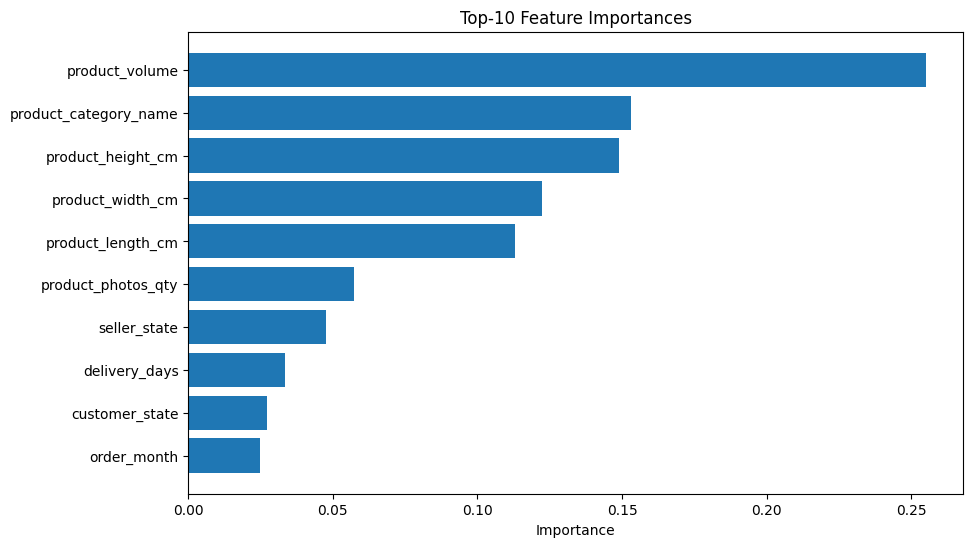

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"][:10][::-1], feat_imp["importance"][:10][::-1])
plt.title("Top-10 Feature Importances")
plt.xlabel("Importance")
plt.show()

Пройдемся по топ-5:
1. Объем товара - ключевой фактор, потому что больше объем -> больше стоимость доставки -> меньше маржа
2. Категория товара - определяет наценку и спрос: электроника и одежда имеет совершенно разные
   
3,4,5: Размеры - Аналогично объему 